<a href="https://colab.research.google.com/github/Fahmudiantosaputro/Tugas_Praktikum-AI-/blob/main/Klasifikasi_Model_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score

1. **pandas** itu untuk membaca data

2. **matplotlib** untuk membuat grafik

3. **sklearn** tools untuk Machine Learning



In [2]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


kode untuk upload dataset berbentuk file, bertujuan untuk mempermudah langkah selanjutnya untuk mengenali data untuk dianalisis.

In [18]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


1. Melihat isi data
2. Memastikan Dataset berhasil dibaca diprogram

In [5]:
df = df.drop('Id', axis=1)

alasan kolom id dihapus yaitu Id cuman nomor urut jadi, tidak berpengaruh ke prediksi atau di model KNN

In [7]:
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

Model KNN tidak bisa membaca teks. jadi, setosa (0), Versicolor (1), Virginica (2).

In [8]:
x = df.drop('Species', axis=1)
y = df['Species']

x bertujuan untuk data input atau fiturnya.
y bertujuan untuk hasil yang ingin diprediksi.

In [9]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

ini penting karena KNN itu memakai jarak dan semisal kalau skala beda hasil menjadi kacau.

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
    )

jadi, code diatas bertujuan untuk mengetahui bahwa 80% itu data latihan dan 20% nya data testing.

In [11]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

*n_neighbors=3* itu melihat 3 tetangga terdekat.

In [12]:
y_pred = knn.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print('Akurasi', accuracy)

Akurasi 1.0


bertujuan unutk mengukur seberapa bagus model.

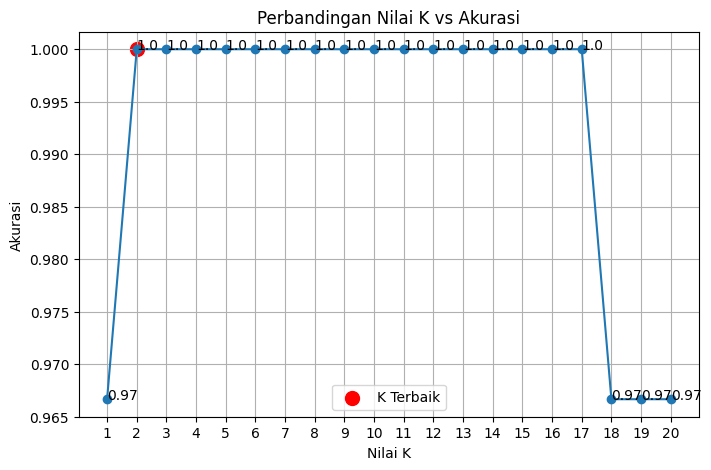

In [17]:
plt.figure(figsize=(8,5))

best_k = k_values[accuracies.index(max(accuracies))]
best_acc = max(accuracies)

plt.plot(k_values, accuracies, marker='o')
plt.scatter(best_k, best_acc, color='red', s=100, label='K Terbaik')

for i, txt in enumerate(accuracies):
    plt.text(k_values[i], accuracies[i], round(txt, 2))

plt.xticks(k_values)
plt.grid()
plt.xlabel("Nilai K")
plt.ylabel("Akurasi")
plt.title("Perbandingan Nilai K vs Akurasi")
plt.legend()

plt.show()

1. Sumbu x nilai k.
2. sumbu y akurasi.
- bertujuan untuk mencari nilai K yang terbaik

In [15]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]


ini bertujuan untuk menunjukan prediksi benar vs salah.

Berdasarkan confusion matrix, model KNN mampu mengklasifikasikan sebagian besar data dengan sangat baik. Dari total 30 data uji, sebanyak 29 data berhasil diprediksi dengan benar, sehingga menghasilkan akurasi sebesar 96,7%. Kesalahan hanya terjadi pada satu data kelas Virginica yang diprediksi sebagai Versicolor. Hal ini menunjukkan bahwa kedua kelas tersebut memiliki karakteristik yang mirip sehingga sedikit sulit dibedakan oleh model. Sementara itu, kelas Setosa dapat diklasifikasikan dengan sempurna tanpa kesalahan.

Analisis model KNN pada dataset Iris dilakukan untuk mengklasifikasikan jenis bunga berdasarkan fitur yang dimiliki, serta mengevaluasi performa model menggunakan akurasi dan confusion matrix. Selain itu, dilakukan pengujian terhadap beberapa nilai K untuk menentukan parameter terbaik yang menghasilkan akurasi tertinggi. Hasil analisis menunjukkan bahwa model KNN mampu bekerja dengan baik dalam mengklasifikasikan data dengan tingkat akurasi yang tinggi.